# Sample Sankey
- sankey plot to display bks set of clb samples
- goal: use sankey to display fates over time of tagged colonies and samples that coincide with nutrient collection dates
- source of code: sctld-SampleSankey.ipynb

In [66]:
library(dplyr)
library(tidyverse)
library(ggplot2)
library(tidyr)
library(purrr)
library(stringr)
library(reshape2) 
library(ggsankey)

In [76]:
colony <- read_csv("/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_ColonyData.csv", show_col_types = FALSE)
sctld_samples <- read.csv("/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_samples.csv")

New names:
• `` -> `...1`


In [78]:
# add colony ids to all dfs
add_colonyid <- function(df) {
    # get transect # 
    df$transect_id <- paste0('T',df$TransectNum)
    # make colony id 
    df$colony_id <- paste(df$transect_id, df$NewTagNum, df$Species,
                                 sep = "_")
    return(df)
}

# apply 
sctld_samples<-add_colonyid(sctld_samples)
colony <- add_colonyid(colony)

In [80]:
# list of nutrient sampling dates 
nut_dates <- as.integer(c(12024,42024, 62024,82024))

In [84]:
#filter sample data for nutrient sampling dates (& UML DNA samples only)
samples<-sctld_samples %>%
    filter(Sample_type == 'Core_RNAlater') %>%
    filter(Month_year %in% nut_dates)
nrow(samples)

# filter colony data to match sequence list 
colony <- colony %>%
    filter(colony_id %in% samples$colony_id)
length(unique(colony$colony_id))

# 148 unique colonies - 300 total samples

[1] 300

[1] 148

In [118]:
# convert condition columns in colony data to month year format 

## change colnames into dates 
# list columns with dates
tf <- grepl('Condition', colnames(colony))
date_col <- colnames(colony)[tf]

# get rid of 'condition' to have col names just contain the date
new_col<-gsub('_Condition', '',date_col)

# convert to mmyydd date format before final date conversion 
formatted_dates <- as.Date(paste0(new_col, "01"), format = "%m%Y%d")

# Format the dates as "Nov 2023", etc.
formatted_labels <- format(formatted_dates, "%b %Y")

# Replace the column names in clb_colony with the formatted labels
colnames(colony)[tf] <- formatted_labels 

# #this is the new list of condiiton columns to use going forward
sample_dates <- c('Jan 2024','Apr 2024','Jun 2024','Aug 2024')

In [89]:
# filter colony data for these dates
colony <- colony %>%
    select(colony_id, Species, any_of(sample_dates))

In [91]:
# convert collection date in sample data to month year format 
samples$dates <- as.Date(samples$CollectionDate, format = "%m/%d/%y")

# convert to mmyyyy and make separate column for written month year 
samples$Month_year <- format(samples$dates, "%b %Y")

# arrange in chronological order 
samples$Month_year<-factor(samples$Month_year, levels = sample_dates) 

In [120]:
lapply(sample_dates, function(col) {
  unique(colony[[col]])
})

[[1]]
 [1] "Diseased"            "CLP,CLB"             "Healthy"            
 [4] "CLP"                 "CLP,DC"              "Not_Visited"        
 [7] "CLB"                 "Diseased_Other, CLP" "DC"                 
[10] NA                   

[[2]]
[1] "Diseased"       "Not_Visited"    "Healthy"        "Diseased, CLP" 
[5] "CLP"            "Diseased_Other" "DC"             "Not_visited"   

[[3]]
[1] "Not_Visited"    "Healthy"        "Diseased"       "DC"            
[5] "Diseased_Other" "Not_visited"    "not_visited"   

[[4]]
[1] "Not_Visited"    "Healthy"        "Diseased"       "Dead"          
[5] "CLP"            "Diseased_Other" "DC"             "CLB"

In [140]:
# conditions to change 

# replace multiple conditions 
# replace NAs 
colony<-colony %>%
  mutate(across(all_of(sample_dates), ~ case_when(
      # make not visited consistent 
    grepl('Not_visited', ., ignore.case=TRUE) ~ 'Not_Visited',
      # clp & clb -> clb 
    . == 'CLP,CLB' ~ 'CLB',
      # clp, dc or dc-> clp 
    . == 'CLB,DC' ~ 'CLB',
    . == 'CLP,DC' ~ 'CLP',
      # ssids are the only ones with DC so just going to make that clp cuz its likely bleaching..can investigate more thoroughly later 
    . == 'DC' ~ 'CLP',
      # if disease or diseased_other & clp -> just make diseased 
    . == 'Diseased_Other, CLP' ~ 'Diseased',
    . == 'Diseased, CLP' ~ 'Diseased',
      # all NAs are T6 that had not been tagged in Jan 2024 
    is.na(.) ~ 'Not_yet_tagged',
    TRUE ~ .
  )))

In [142]:
sankeydf <- data.frame()
for(id in unique(colony$colony_id)){
    # print(id)
    #create dfs for individual colonies 
    df <- colony %>%
        filter(colony_id == id)
    # print(df)

    # pivot longer
    sankdf <- df %>% 
     make_long(all_of(sample_dates)) %>%
     mutate(colony_id = id) 
    # print("sankdf")
    # print(sankdf)

    # combine into 1 df
   sankeydf <- sankeydf %>%
     bind_rows(sankdf)
    # print("sankeydf")
    # print(sankeydf)
}
# print commands are for troubleshooting

In [143]:
testid = 'T1_2_PAST' 
tail(strsplit(testid, "_")[[1]], 1)

[1] "PAST"

In [144]:
# add species labels and sample statuses for each colony id 

# filter samples to match sankeydf format 
sampledf <- samples %>% 
    select(colony_id, Month_year, Health_status) %>%
    rename(x = Month_year,
          sample_condition = Health_status)

# merge
sankey <- sankeydf %>%
    left_join(sampledf,
         # match sample conditions to 'x' (first time point in the set) 
             by = c('colony_id','x')) %>%
        # add species grouping based on colony id 
    rowwise() %>%    
    mutate(species = tail(strsplit(colony_id, "_")[[1]], 1))

head(sankey,10)

x,node,next_x,next_node,colony_id,sample_condition,species
<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
Jan 2024,Diseased,Apr 2024,Diseased,T1_1_SSID,NA,SSID
Apr 2024,Diseased,Jun 2024,Not_Visited,T1_1_SSID,Diseased_Margin,SSID
Jun 2024,Not_Visited,Aug 2024,Not_Visited,T1_1_SSID,NA,SSID
Aug 2024,Not_Visited,NA,NA,T1_1_SSID,NA,SSID
Jan 2024,CLB,Apr 2024,Not_Visited,T1_2_PAST,NA,PAST
Apr 2024,Not_Visited,Jun 2024,Healthy,T1_2_PAST,NA,PAST
Jun 2024,Healthy,Aug 2024,Healthy,T1_2_PAST,Healthy,PAST
Aug 2024,Healthy,NA,NA,T1_2_PAST,Healthy,PAST
Jan 2024,Healthy,Apr 2024,Diseased,T1_3_SSID,Healthy,SSID


In [145]:
unique(sankey$node)

[1] "Diseased"       "Not_Visited"    "CLB"            "Healthy"       
[5] "CLP"            "Dead"           "Diseased_Other" "Not_yet_tagged"

In [137]:
# write_csv(x = sankey, file = 'sankeydf.csv')

In [154]:
sank_colors = c('Dead'='tomato3',
                'Healthy'='palegreen3',
                'CLP'='lightgoldenrod2',
                'CLB'='cadetblue1',
                 'DC' = 'thistle2',
                 'Diseased' = 'salmon1',
                 'Diseased_Other' = 'coral3',
                 'Not_Visited' = 'honeydew2',
                 'Not_yet_tagged' = 'gray78')


# sank_colors = c('Dead'='black','Healthy'='forestgreen',
#                  'DC' = 'blueviolet',
#                  'Diseased' = 'firebrick',
#                  'Diseased_Other' = 'coral3',
#                  'Not_Visited' = 'gray30',
#                  'Unknown' = 'gray78')

In [147]:
options(repr.plot.width=12, repr.plot.height=10)

In [140]:
# investigate any dups 
# dupes <- mcav %>%
#   count(x, colony_id) %>%
#   filter(n > 1)
# dupes

# #remove 
# mcav <- mcav %>%
#   distinct(x, colony_id, .keep_all = TRUE)

# i dont think this ended up being necessary?

[1] "Missing samples:"
# A tibble: 11 × 3
   colony_id  x        node    
   <chr>      <fct>    <chr>   
 1 T1_1_SSID  Jan 2024 Diseased
 2 T1_5_SSID  Jan 2024 Diseased
 3 T1_9_SSID  Jan 2024 Diseased
 4 T1_11_SSID Jan 2024 Diseased
 5 T1_16_SSID Jan 2024 Diseased
 6 T1_17_SSID Jan 2024 Diseased
 7 T2_52_SSID Jan 2024 Diseased
 8 T3_3_SSID  Jan 2024 Diseased
 9 T3_19_SSID Jan 2024 Diseased
10 T3_28_SSID Jan 2024 Diseased
11 T3_36_SSID Jan 2024 Healthy 


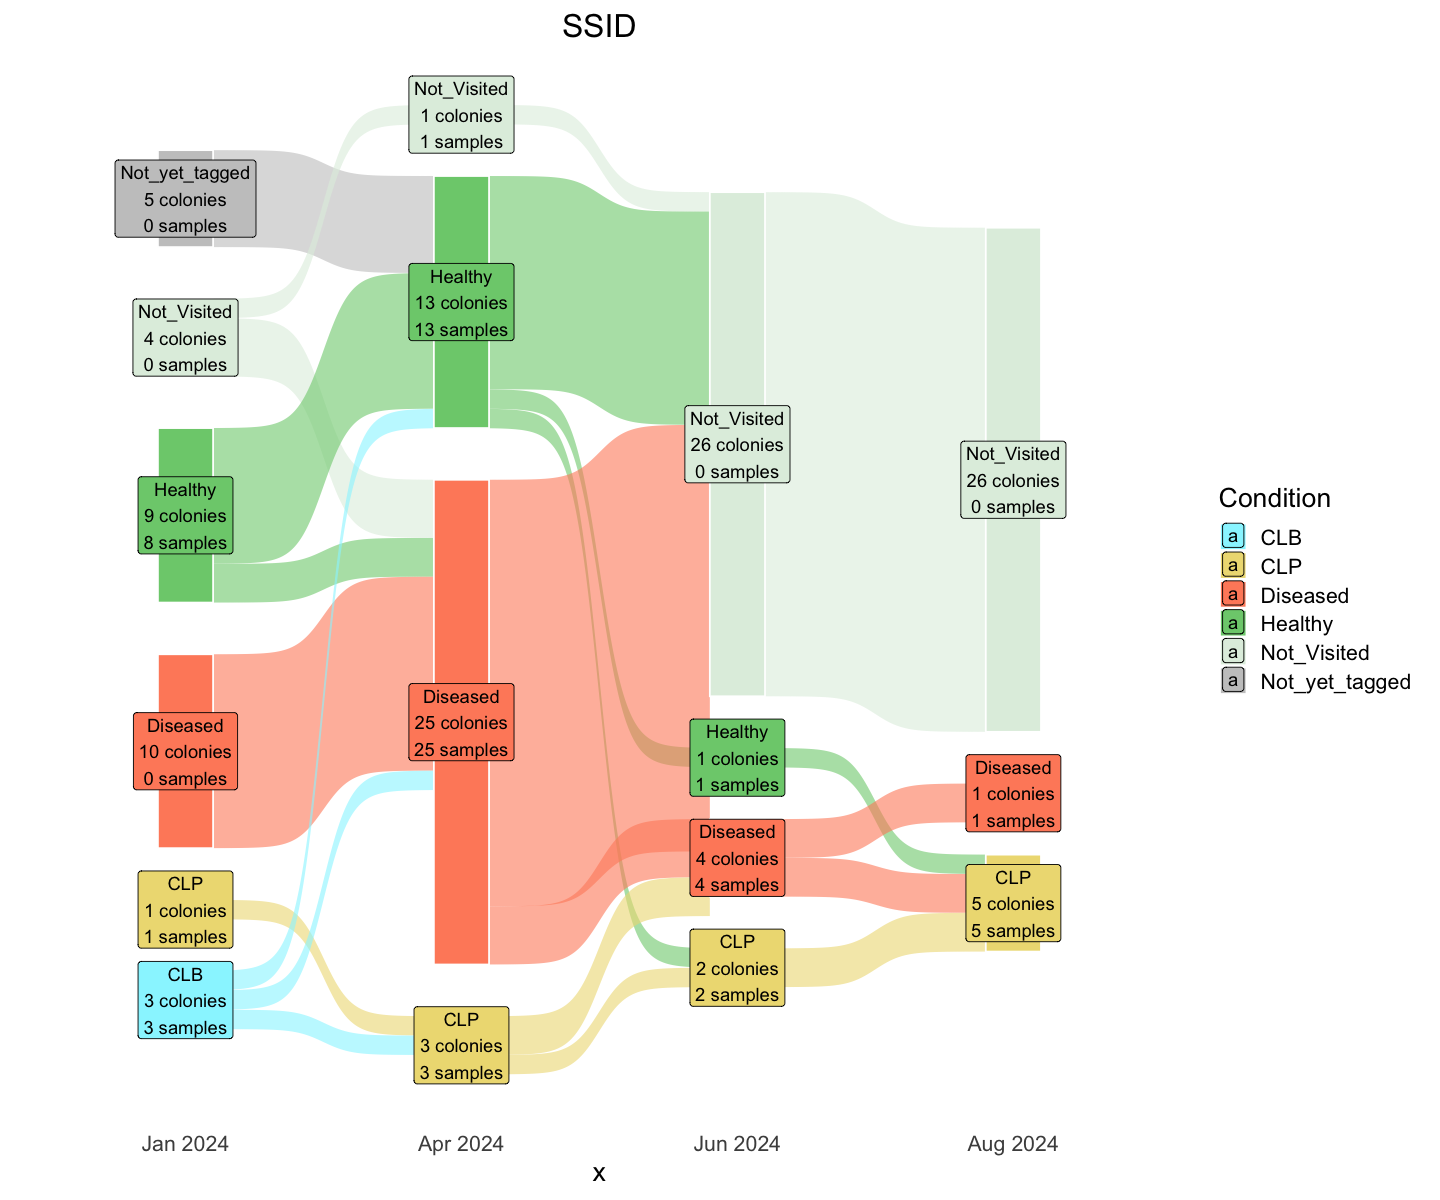

[1] "Missing samples:"
# A tibble: 7 × 3
  colony_id  x        node   
  <chr>      <fct>    <chr>  
1 T1_2_PAST  Jan 2024 CLB    
2 T1_21_PAST Jun 2024 Healthy
3 T3_7_PAST  Jan 2024 CLP    
4 T3_10_PAST Jan 2024 Healthy
5 T3_13_PAST Jan 2024 Healthy
6 T3_18_PAST Jan 2024 Healthy
7 T5_42_PAST Apr 2024 Healthy


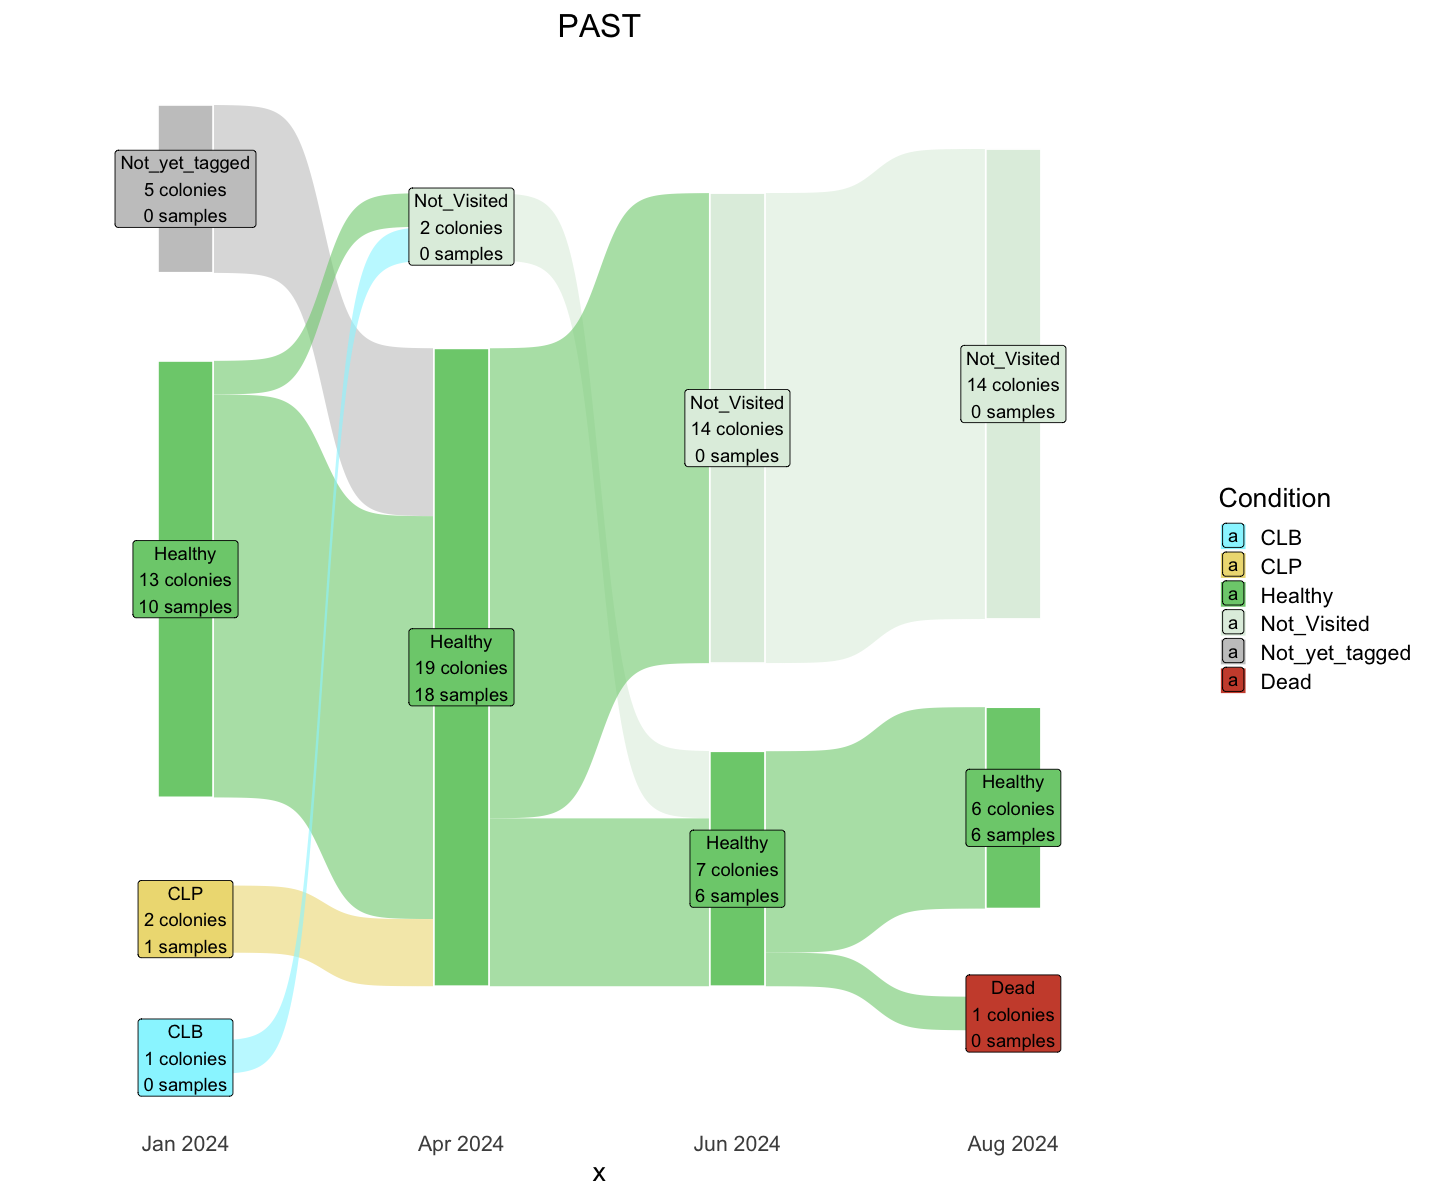

[1] "Missing samples:"
# A tibble: 4 × 3
  colony_id  x        node   
  <chr>      <fct>    <chr>  
1 T1_7_MCAV  Jan 2024 Healthy
2 T2_59_MCAV Jan 2024 Healthy
3 T3_71_MCAV Jan 2024 Healthy
4 T4_28_MCAV Jan 2024 Healthy


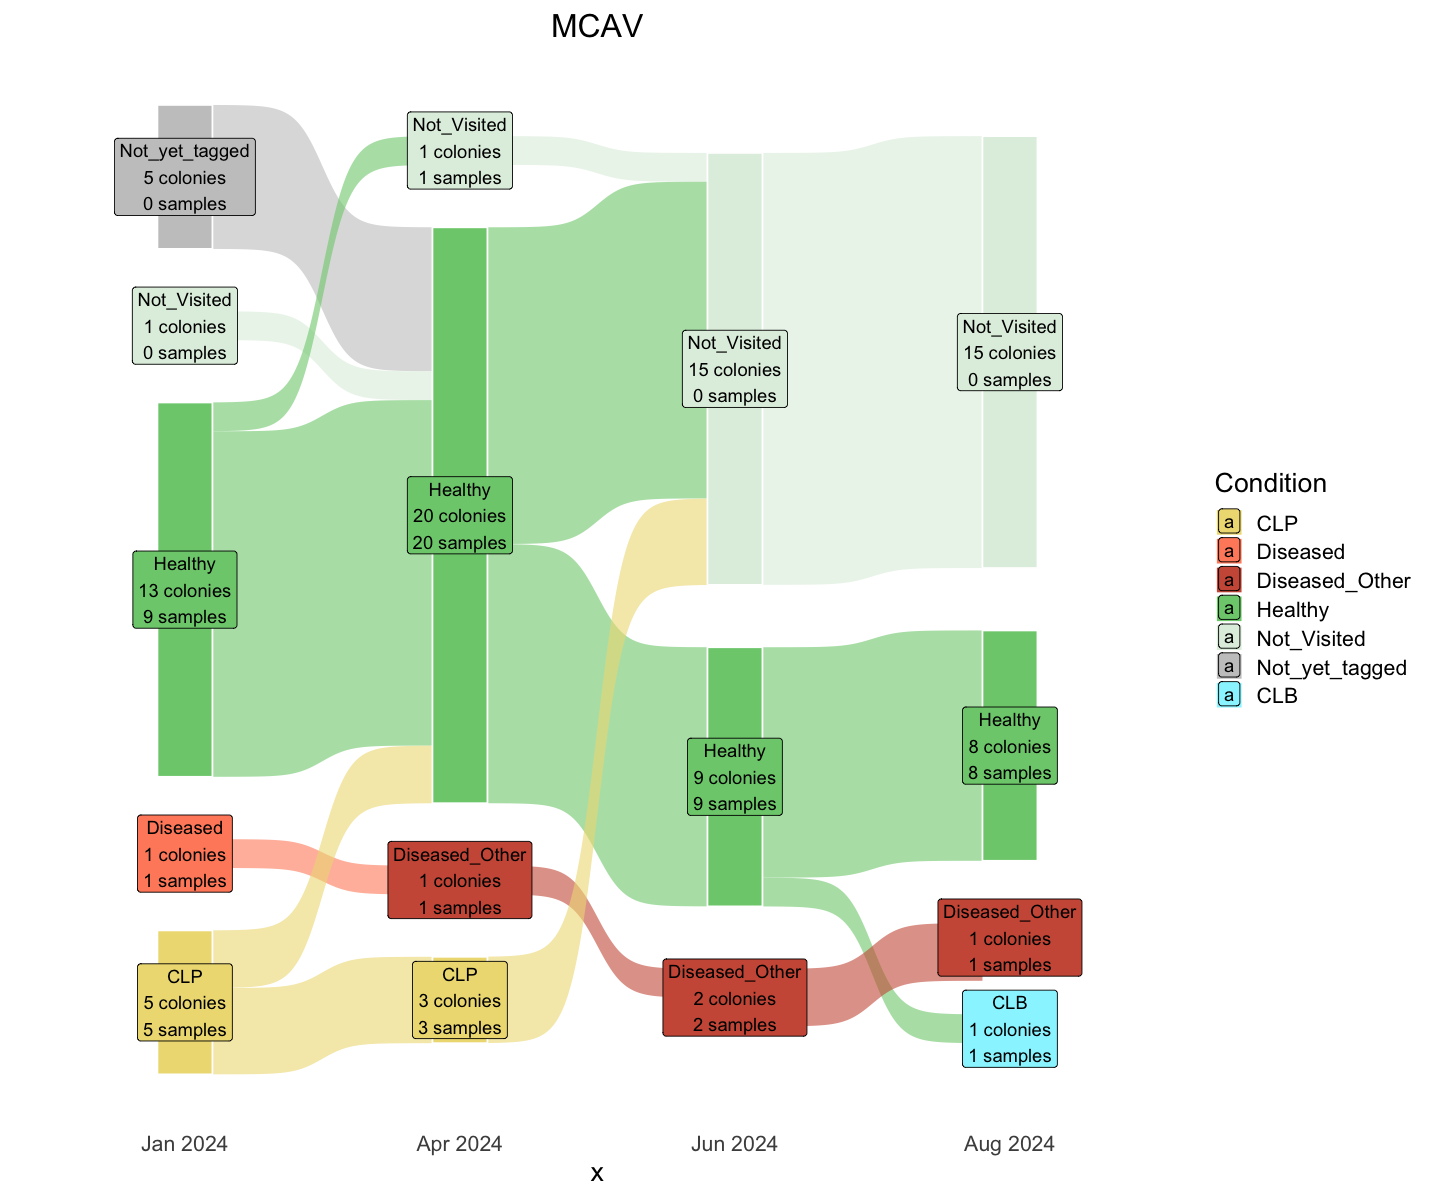

[1] "Missing samples:"
# A tibble: 3 × 3
  colony_id  x        node   
  <chr>      <fct>    <chr>  
1 T2_54_PSTR Jan 2024 CLP    
2 T3_4_PSTR  Jan 2024 Healthy
3 T3_75_PSTR Jan 2024 CLP    


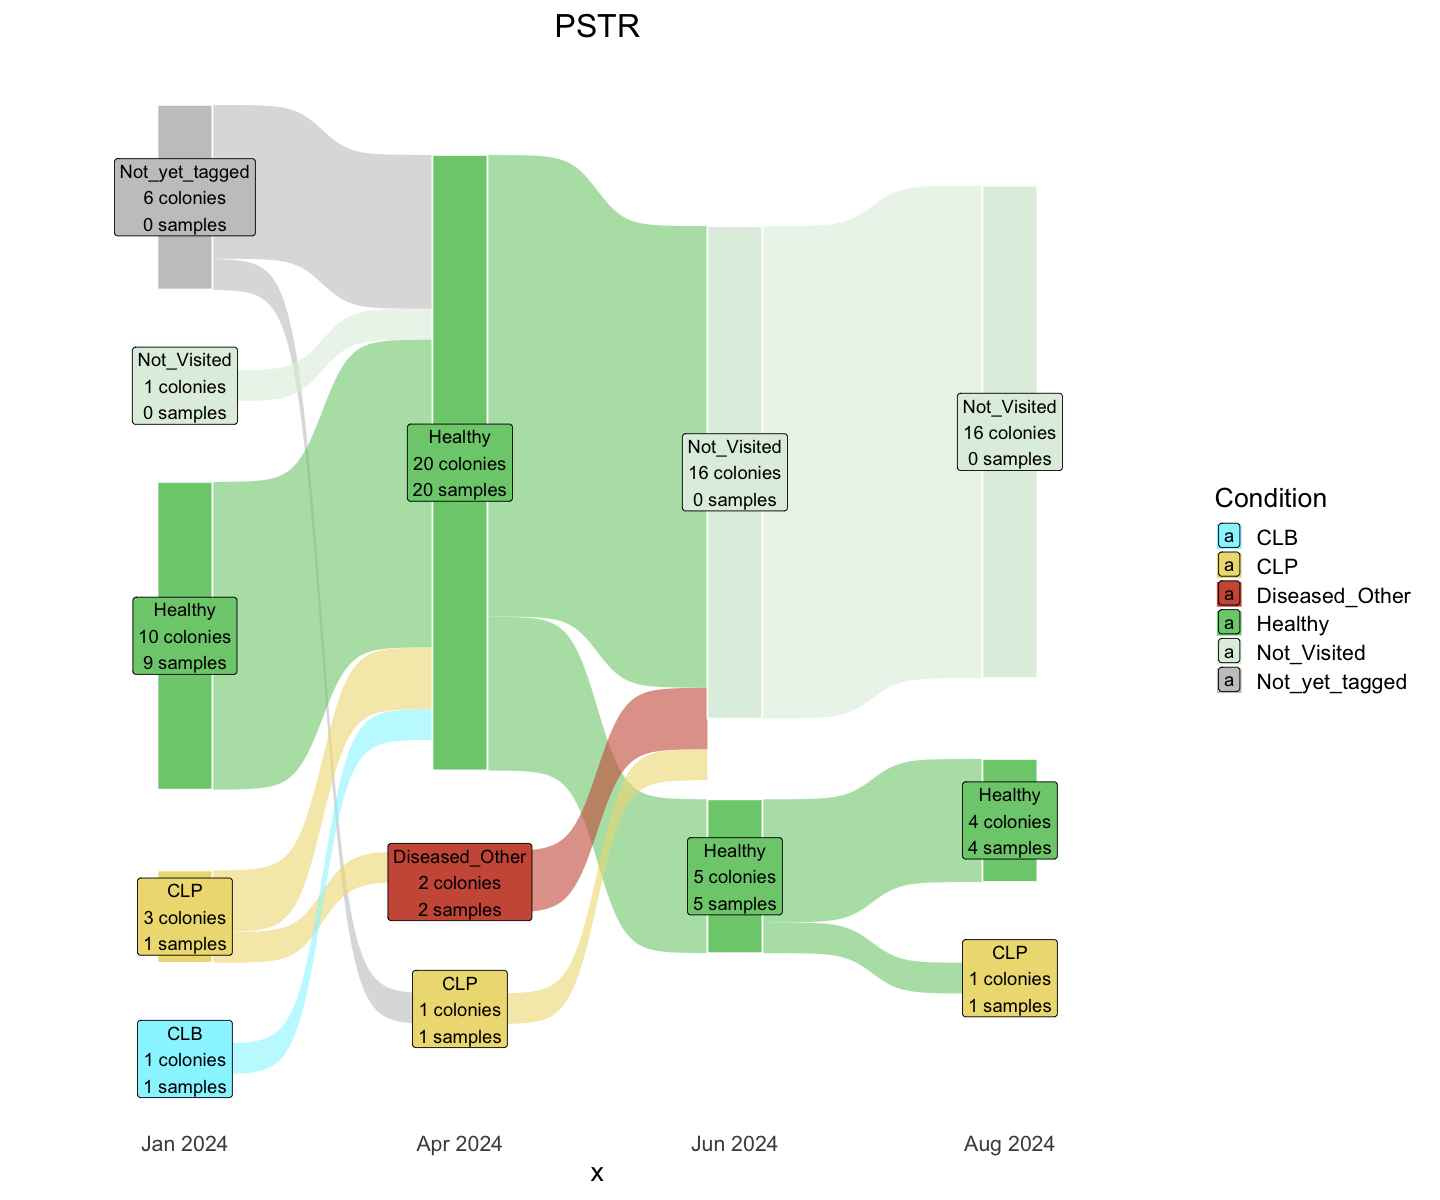

[1] "Missing samples:"
# A tibble: 5 × 3
  colony_id  x        node    
  <chr>      <fct>    <chr>   
1 T1_22_OANN Jan 2024 Diseased
2 T1_23_OANN Jan 2024 Healthy 
3 T2_30_OANN Jan 2024 CLP     
4 T3_68_OANN Jan 2024 Healthy 
5 T3_72_OANN Jan 2024 Healthy 


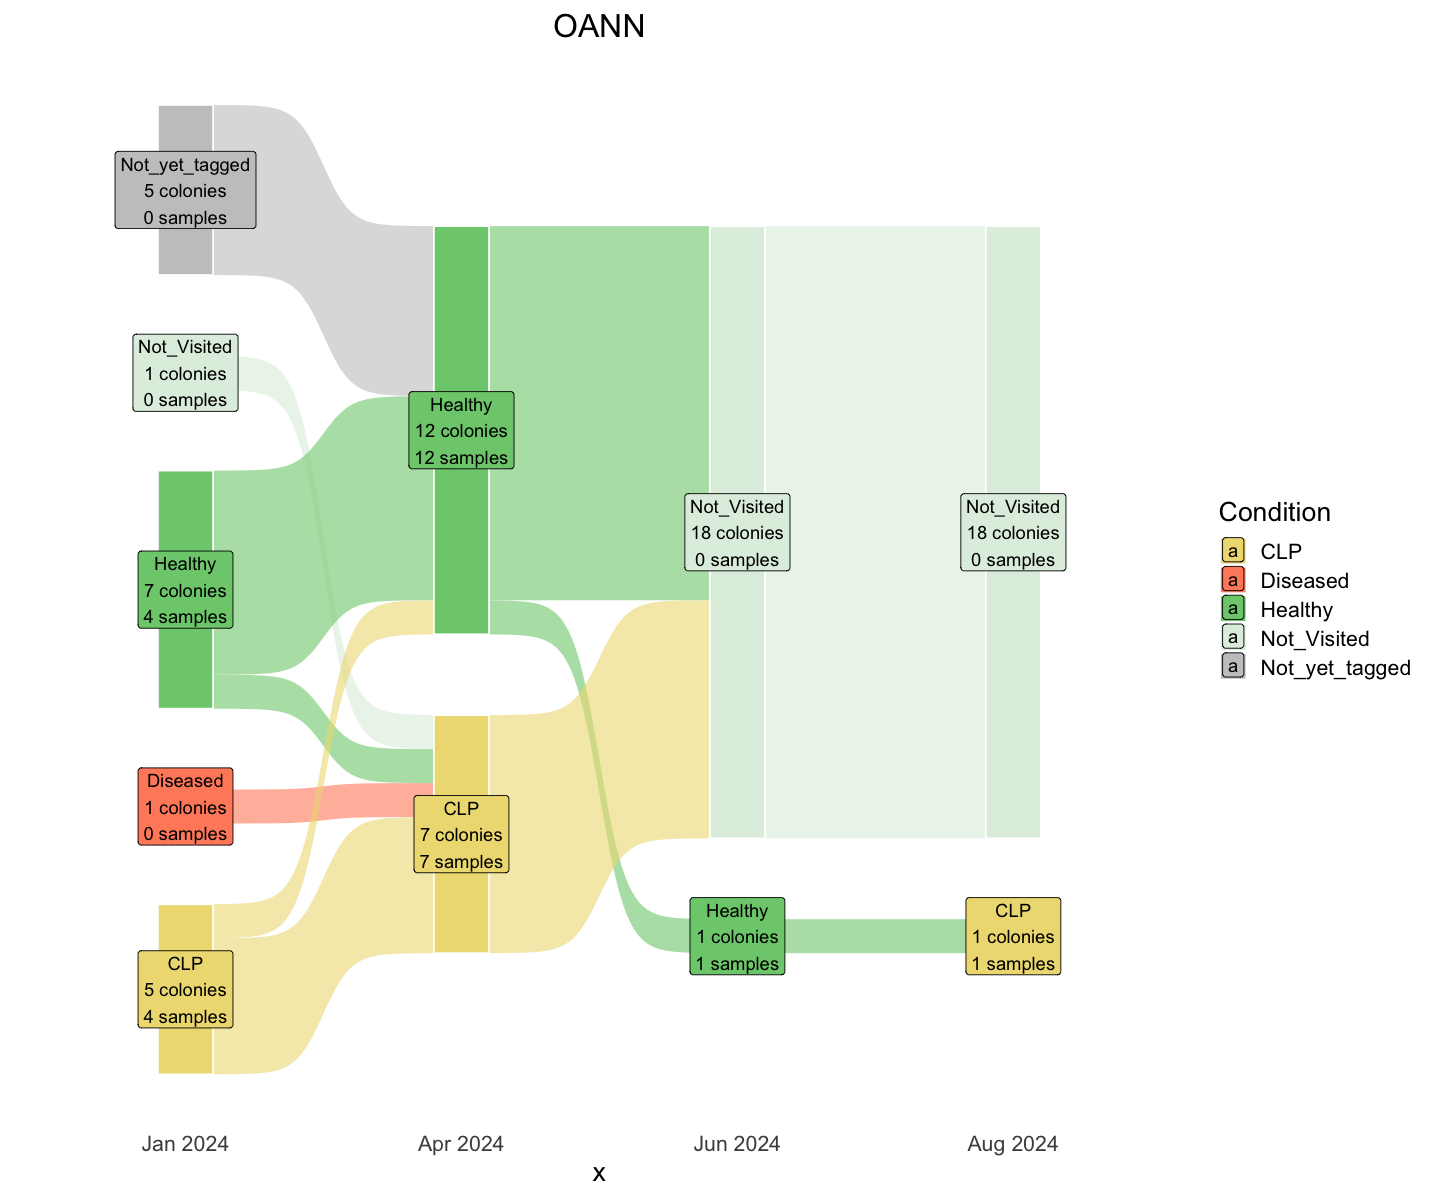

[1] "Missing samples:"
# A tibble: 8 × 3
  colony_id  x        node   
  <chr>      <fct>    <chr>  
1 T1_27_DLAB Jan 2024 Healthy
2 T1_35_DLAB Jan 2024 CLP    
3 T2_31_DLAB Jan 2024 Healthy
4 T2_78_DLAB Jan 2024 Healthy
5 T3_69_DLAB Jan 2024 CLP    
6 T3_73_DLAB Jan 2024 Healthy
7 T4_43_DLAB Jan 2024 Healthy
8 T4_93_DLAB Jan 2024 Healthy


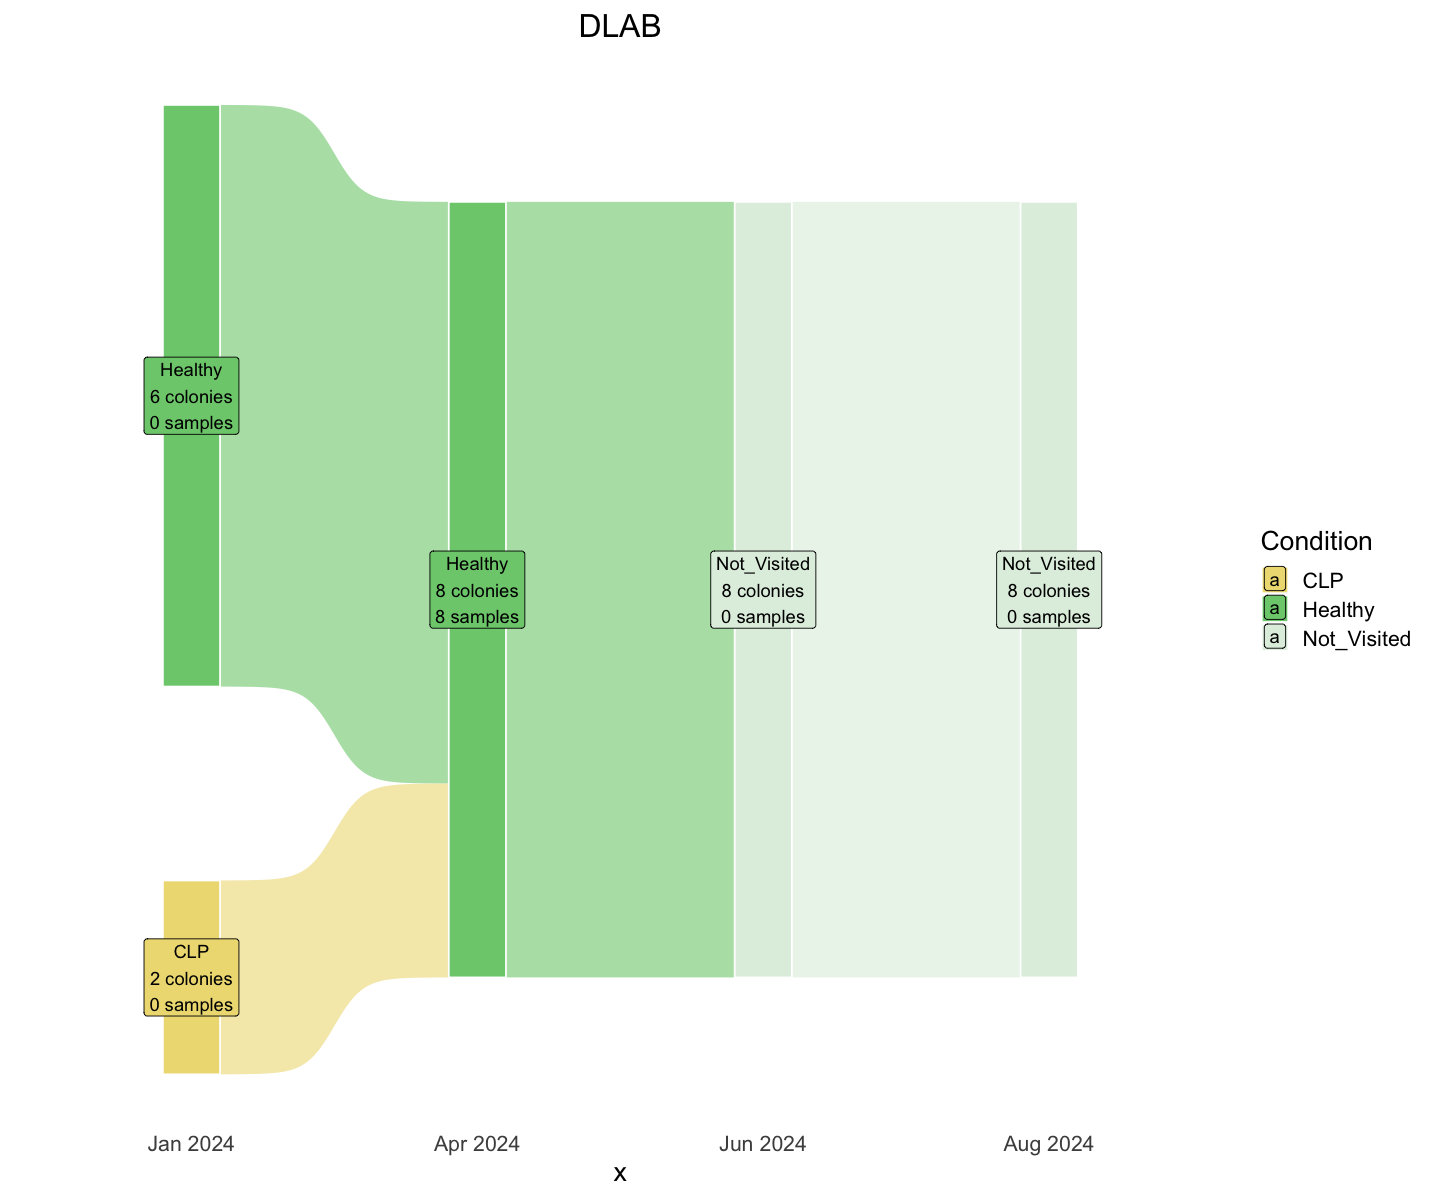

[1] "Missing samples:"
# A tibble: 6 × 3
  colony_id   x        node   
  <chr>       <fct>    <chr>  
1 T2_29_OFAV  Jan 2024 Healthy
2 T2_80_OFAV  Jan 2024 CLP    
3 T3_38_OFAV  Aug 2024 Healthy
4 T4_77_OFAV  Jan 2024 Healthy
5 T4_92_OFAV  Jan 2024 Healthy
6 T4_100_OFAV Jan 2024 Healthy


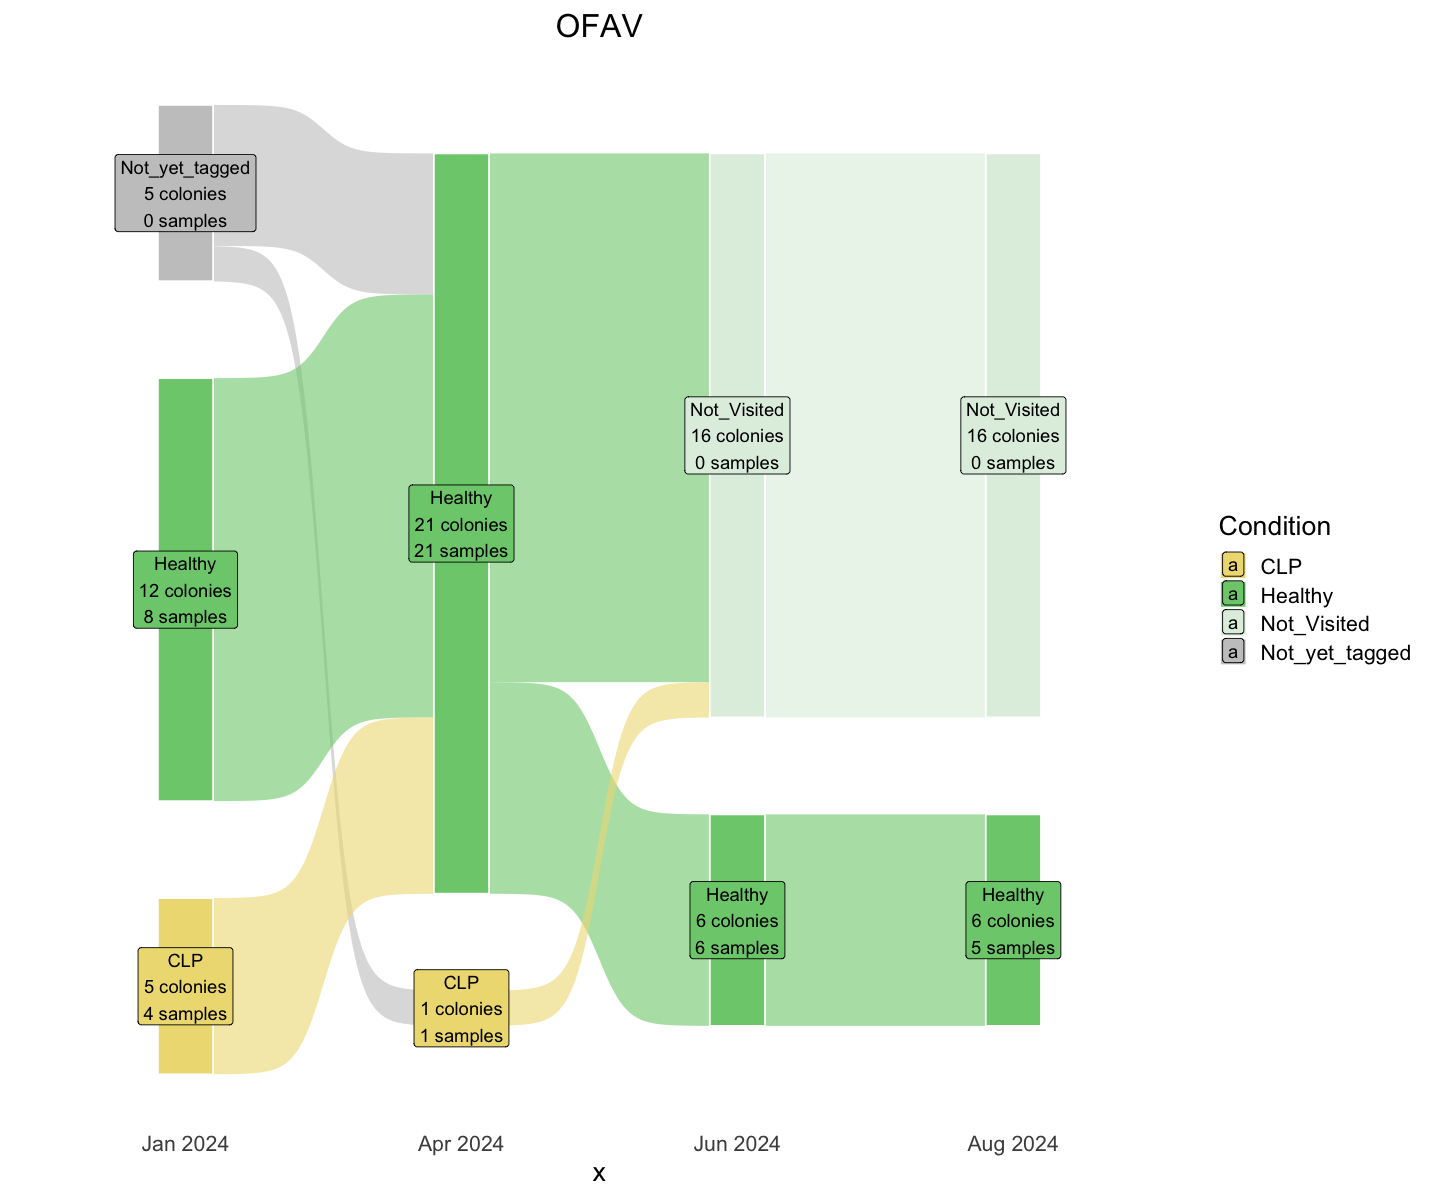

In [155]:
# plot all
species_list<-unique(sankey$species)

for (specie in species_list){
    df <-sankey %>%
        filter(species == specie)

    # for each node type, how many samples are there  
    df_count <- df %>%
      group_by(x, node) %>%
            # sum colonies per node & time point (x)
      mutate(colony_count = n(),
             # sum samples per node and time point grouping 
             n_samples = sum(!is.na(sample_condition), na.rm = TRUE),
             label_text = paste0(node, "\n", 
                            colony_count, " colonies\n",
                            n_samples, " samples")
            ) %>% 
    ungroup()

    # if condition count != sample count, print colony ID that has NA as sample_condition (wasn't sampled) 
    missing_samples_list<-df_count %>%
      filter(!node %in% c('Dead', 'Not_Visited', 'Not_yet_tagged')) %>%
      filter(colony_count != n_samples & is.na(sample_condition)) %>%
      select(colony_id, x, node)
      # mutate(missing_samples = paste(x,node, sep = " | ")) %>%
      # pull(missing_samples, colony_id)

    # plot
    plot<-ggplot(df_count, aes(x = x, next_x = next_x,
                        node = node, next_node = next_node,
                        fill = factor(node))) +
    geom_sankey(flow.alpha = 0.6, node.color = "white", width = 0.2) +
    geom_sankey_label(aes(label = label_text)) +
    scale_fill_manual("Condition", values = sank_colors) +
    theme_sankey(base_size = 16) +
    theme(plot.title = element_text(hjust = 0.5))+
    ggtitle(paste(specie))
    
    print(plot)
    
# print if there are missing samples
    # if missing_samples tibble has any rows, print them 
    if (nrow(missing_samples_list) > 0) {
      print("Missing samples:")
      print(missing_samples_list)
    }
    }

# ssid looks like theres 1 sample that was not visited the whole time.. maybe it was previously dead 
# 1 mcav called diseased then diseased_other -> should probably just make this consistent 
# pstr - in april we have 23 colonies, but in the rest of the dates we only have 21?